##import libraries

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

##Load Data

In [3]:
data=sns.load_dataset('titanic')
print(data.head())
data_backup = data.copy()

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


##information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

##Data Cleaning

In [7]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [8]:
# drop column deck -> has over nulls
data=data.drop('deck',axis=1)
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [9]:
# 2 nulls for embarked -> fill with mode
mode=data['embarked'].mode()
data['embarked']=data['embarked'].fillna(mode[0])
data['embarked']


,embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [10]:
# 2 nulls for embarked_town ->fill with mode
mode=data['embark_town'].mode()
data['embark_town']=data['embark_town'].fillna(mode[0])
data['embark_town']


,embark_town
0,Southampton
1,Cherbourg
2,Southampton
3,Southampton
4,Southampton
...,...
886,Southampton
887,Southampton
888,Southampton
889,Cherbourg


In [11]:
# fill age for null
mean_age=data['age'].mean()
mean_age=int(mean_age)
data['age']=data['age'].fillna(mean_age)
data['age']

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,29.0
889,26.0


In [12]:
data.isnull().sum()
# data cleaned!

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


##EDA

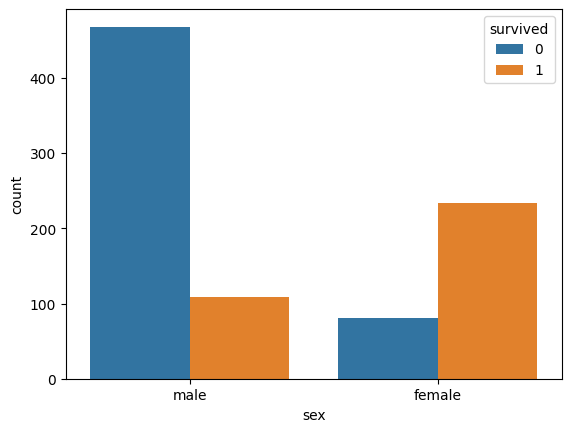

In [13]:
#Relationship between the number of females and males that survived
# print(type(plt)) --> <class 'module'>

sns.countplot(x='sex', data=data, hue='survived')
plt.show()

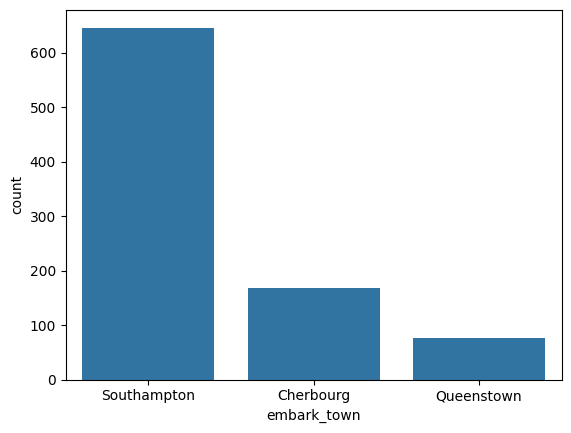

In [14]:
# number of people for each town
sns.countplot(x='embark_town', data=data)
plt.show()

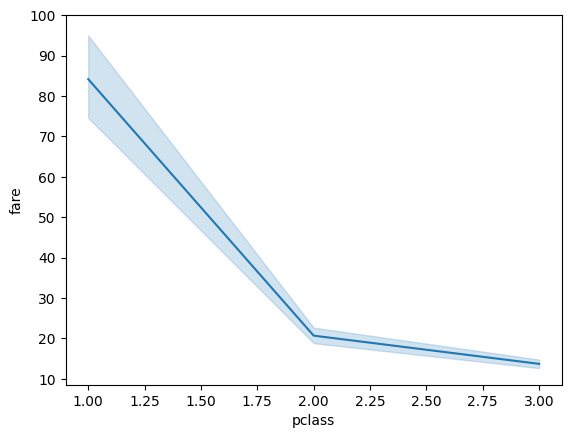

In [15]:
from numpy._core.defchararray import index
#relation between Classes and fare
sns.lineplot(data=data,x='pclass',y='fare')
plt.yticks([10,20,30,40,50,60,70,80,90,100])
plt.show()

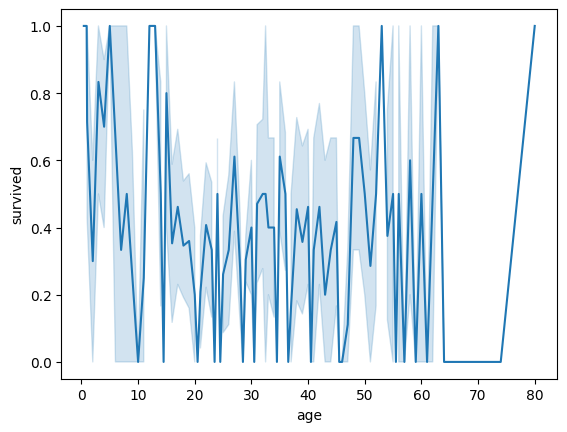

In [16]:
#relation between survived people and their age
sns.lineplot(data=data,x='age',y='survived')
plt.show()


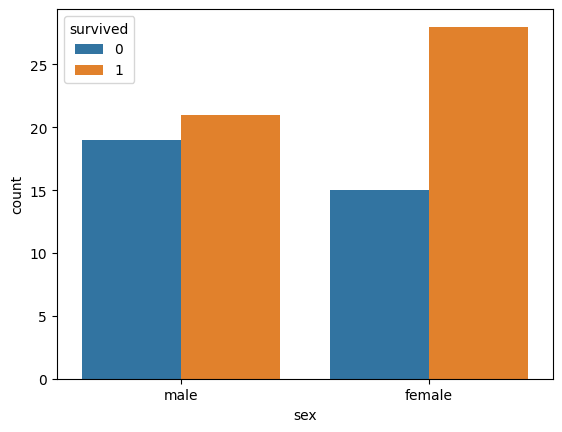

In [17]:
# number of female children and male children survived
child_data = data[data['who'] == 'child']

sns.countplot(data=child_data, x='sex', hue='survived')
plt.show()

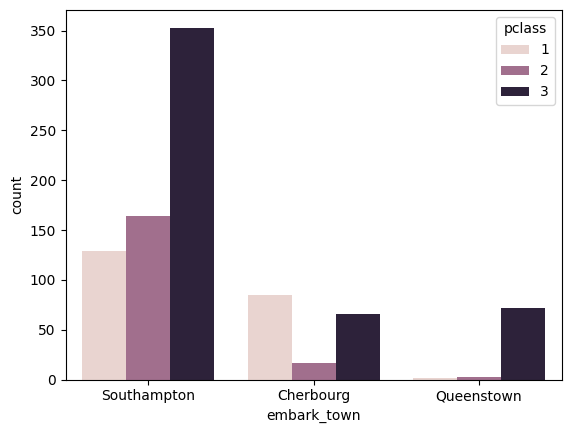

In [18]:
#nNumber of people in every class from each town
sns.countplot(x='embark_town', hue='pclass', data=data)
plt.show()


##Feature engineering

In [19]:
#family
family_size=data['sibsp']+data['parch']+1
data['family_size']=family_size
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,1
888,0,3,female,29.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1


In [20]:
#who is adult woman?
adult_female=(data['sex']=='female') & (data['who']=='woman')
data['adult_female']=adult_female
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,adult_female
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,True
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True,1,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,1,True
888,0,3,female,29.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False,4,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1,False


##machine learning

##Encoded

In [22]:
data["numeric_sex"]=data["sex"].map({
    "male": 0,
    "female": 1
})

l_en=LabelEncoder()

data["adult_female"]=l_en.fit_transform(data["adult_female"])
data["adult_male"]=l_en.fit_transform(data["adult_male"])
data["adult"]=data["adult_male"]+data["adult_female"]
data=pd.get_dummies(data, columns=["embarked"])
data["embarked_C"]=l_en.fit_transform(data["embarked_C"])
data["embarked_S"]=l_en.fit_transform(data["embarked_S"])
data["embarked_Q"]=l_en.fit_transform(data["embarked_Q"])
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_size,adult_female,numeric_sex,adult,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,Third,man,1,Southampton,no,False,2,0,0,1,0,0,1
1,1,1,female,38.0,1,0,71.2833,First,woman,0,Cherbourg,yes,False,2,1,1,1,1,0,0
2,1,3,female,26.0,0,0,7.9250,Third,woman,0,Southampton,yes,True,1,1,1,1,0,0,1
3,1,1,female,35.0,1,0,53.1000,First,woman,0,Southampton,yes,False,2,1,1,1,0,0,1
4,0,3,male,35.0,0,0,8.0500,Third,man,1,Southampton,no,True,1,0,0,1,0,0,1


##get target column

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data["Fare"] = scaler.fit_transform(data[["fare"]])

In [24]:
#control outliers
Q1 = data["fare"].quantile(0.25)
Q3 = data["fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[
    (data["fare"] < lower) |
    (data["fare"] > upper)
]
df = data[
    (data["fare"] >= lower) &
    (data["fare"] <= upper)
]
df

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,...,alive,alone,family_size,adult_female,numeric_sex,adult,embarked_C,embarked_Q,embarked_S,Fare
0,0,3,male,22.0,1,0,7.2500,Third,man,1,...,no,False,2,0,0,1,0,0,1,0.014151
2,1,3,female,26.0,0,0,7.9250,Third,woman,0,...,yes,True,1,1,1,1,0,0,1,0.015469
3,1,1,female,35.0,1,0,53.1000,First,woman,0,...,yes,False,2,1,1,1,0,0,1,0.103644
4,0,3,male,35.0,0,0,8.0500,Third,man,1,...,no,True,1,0,0,1,0,0,1,0.015713
5,0,3,male,29.0,0,0,8.4583,Third,man,1,...,no,True,1,0,0,1,0,1,0,0.016510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,Second,man,1,...,no,True,1,0,0,1,0,0,1,0.025374
887,1,1,female,19.0,0,0,30.0000,First,woman,0,...,yes,True,1,1,1,1,0,0,1,0.058556
888,0,3,female,29.0,1,2,23.4500,Third,woman,0,...,no,False,4,1,1,1,0,0,1,0.045771
889,1,1,male,26.0,0,0,30.0000,First,man,1,...,yes,True,1,0,0,1,1,0,0,0.058556


In [32]:
X = data[["numeric_sex","age","fare","pclass","family_size","embarked_C","embarked_S","embarked_Q"]]
y = data["survived"]
X.head()

,numeric_sex,age,fare,pclass,family_size,embarked_C,embarked_S,embarked_Q
0,0,22.0,7.2500,3,2,0,1,0
1,1,38.0,71.2833,1,2,1,0,0
2,1,26.0,7.9250,3,1,0,1,0
3,1,35.0,53.1000,1,2,0,1,0
4,0,35.0,8.0500,3,1,0,1,0


##apply model

In [33]:
model=LogisticRegression(max_iter=1000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

##

In [27]:
# Make predictions
y_pred_proba = model.predict_proba(X_test)#[:,1]
y_pred_proba

array([[0.89308127, 0.10691873],
       [0.77845567, 0.22154433],
       [0.86521489, 0.13478511],
       [0.1223443 , 0.8776557 ],
       [0.23787694, 0.76212306],
       [0.06715301, 0.93284699],
       [0.32317462, 0.67682538],
       [0.89550895, 0.10449105],
       [0.24229035, 0.75770965],
       [0.09391807, 0.90608193],
       [0.64843566, 0.35156434],
       [0.9308077 , 0.0691923 ],
       [0.58739619, 0.41260381],
       [0.85012432, 0.14987568],
       [0.8028479 , 0.1971521 ],
       [0.06823471, 0.93176529],
       [0.68305421, 0.31694579],
       [0.32312814, 0.67687186],
       [0.75521346, 0.24478654],
       [0.66903884, 0.33096116],
       [0.87897311, 0.12102689],
       [0.59174649, 0.40825351],
       [0.36192009, 0.63807991],
       [0.86480756, 0.13519244],
       [0.89275812, 0.10724188],
       [0.93058884, 0.06941116],
       [0.52973565, 0.47026435],
       [0.77729656, 0.22270344],
       [0.91764106, 0.08235894],
       [0.39732171, 0.60267829],
       [0.

In [28]:
# Make predictions
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [29]:
y_test

,survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


In [30]:
#Accuracy
print(model.score(X_test, y_test))

0.8044692737430168


In [31]:
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Precision Score: ", precision_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))

Accuracy Score:  0.8044692737430168
Precision Score:  0.782608695652174
Recall Score:  0.7297297297297297
F1 Score:  0.7552447552447552
